# Package Import

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# Data Collection

In [2]:
chili_df = pd.read_csv('dataset/cabai_rawit_combined.csv')
chili_df = chili_df.sort_values('Date').reset_index(drop=True)
chili_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1604 entries, 0 to 1603
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1604 non-null   object 
 1   Price   1542 non-null   float64
dtypes: float64(1), object(1)
memory usage: 25.2+ KB


In [3]:
chili_df.shape

(1604, 2)

# Exploratory Data Analysis

## Descriptive

In [4]:
print(chili_df['Price'].describe())

count      1542.000000
mean      50881.963035
std       20397.562678
min       24077.000000
25%       34103.750000
50%       43879.500000
75%       65787.250000
max      114246.000000
Name: Price, dtype: float64


## Dispersion Analysis

In [5]:
std_price = chili_df['Price'].std()
var_price = chili_df['Price'].var()
min_price = chili_df['Price'].min()
max_price = chili_df['Price'].max()
range_price = max_price - min_price

print(f"Standard Deviation : {std_price:.2f}")
print(f"Variance           : {var_price:.2f}")
print(f"Min                : {min_price:.2f}")
print(f"Max                : {max_price:.2f}")
print(f"Range              : {range_price:.2f}")

Standard Deviation : 20397.56
Variance           : 416060563.19
Min                : 24077.00
Max                : 114246.00
Range              : 90169.00


## IQR Analysis

In [6]:
Q1 = chili_df['Price'].quantile(0.25)
Q2 = chili_df['Price'].quantile(0.50)
Q3 = chili_df['Price'].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1 : {Q1:.2f}")
print(f"Q2 : {Q2:.2f}")
print(f"Q3 : {Q3:.2f}")
print(f"IQR: {IQR:.2f}")

# Outlier bounds
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"\nLower Bound : {lower_bound:.2f}")
print(f"Upper Bound : {upper_bound:.2f}")

Q1 : 34103.75
Q2 : 43879.50
Q3 : 65787.25
IQR: 31683.50

Lower Bound : -13421.50
Upper Bound : 113312.50


In [ ]:
outliers = chili_df[
    (chili_df['Price'] < lower_bound) |
    (chili_df['Price'] > upper_bound)
]

print("Total Outliers:", len(outliers))

outlier_percentage = (
    len(outliers) / len(chili_df)
) * 100

print(f"Outlier Percentage: {outlier_percentage:.2f}%")

print("\nSample Outliers:")
print(outliers.head())


OUTLIER ANALYSIS
Total Outliers: 1
Outlier Percentage: 0.06%

Sample Outliers:
           Date     Price
119  03/03/2025  114246.0


## Distribution Analysis

In [10]:
skewness = skew(chili_df['Price'])
kurt = kurtosis(chili_df['Price'])

print(f"Skewness : {skewness:.4f}")
print(f"Kurtosis : {kurt:.4f}")

# Interpretation
if skewness > 0:
    print("Distribution: Right-Skewed")
elif skewness < 0:
    print("Distribution: Left-Skewed")
else:
    print("Distribution: Symmetric")

Skewness : nan
Kurtosis : nan
Distribution: Symmetric


## Histogram

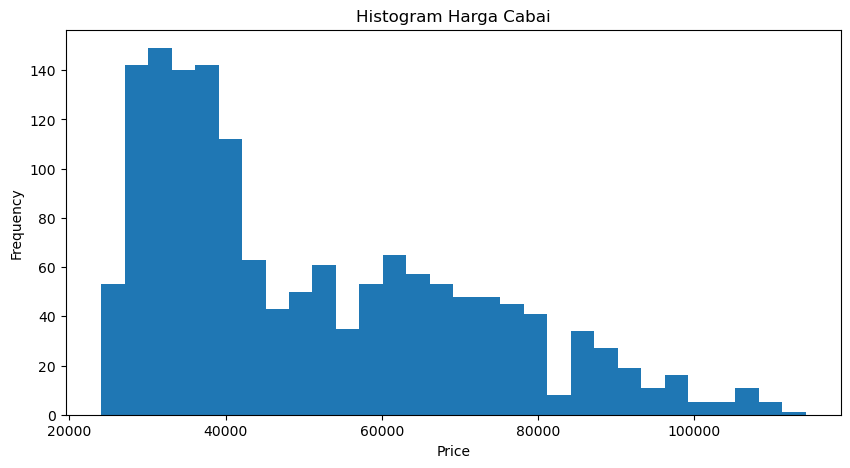

In [11]:
plt.figure(figsize=(10,5))

plt.hist(chili_df['Price'], bins=30)

plt.title("Histogram Harga Cabai")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

# Data Preprocessing

In [ ]:
# Preprocessing
chili_df['Date'] = pd.to_datetime(chili_df['Date'], format='%d/%m/%Y')
chili_df['Price'] = chili_df['Price'].interpolate(method='linear')

# Outlier Handling
chili_df['Price_Smooth'] = chili_df['Price'].rolling(3).mean()

# =========================
# PLOT HARIAN
# =========================
plt.figure(figsize=(10,5))
sns.lineplot(data=chili_df, x='Date', y='Price', marker='o')
sns.lineplot(data=chili_df, x='Date', y='Price_Smooth', marker='s')

plt.title('Harga Harian')
plt.xlabel('Tanggal')
plt.ylabel('Price')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# =========================
# RESAMPLE BULANAN
# =========================
monthly = chili_df.resample('M', on='Date').mean(numeric_only=True)

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly, x=monthly.index, y='Price', marker='o')
sns.lineplot(data=monthly, x=monthly.index, y='Price_Smooth', marker='s')

plt.title('Rata-rata Harga Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Average Price')

plt.tight_layout()
plt.show()

# =========================
# RESAMPLE TAHUNAN
# =========================
yearly = chili_df.resample('Y', on='Date').mean(numeric_only=True)

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly, x=yearly.index, y='Price', marker='o')
sns.lineplot(data=yearly, x=yearly.index, y='Price_Smooth', marker='s')

plt.title('Rata-rata Harga Tahunan')
plt.xlabel('Tahun')
plt.ylabel('Average Price')

plt.tight_layout()
plt.show()

In [ ]:
# AMBIL TAHUN DAN BULAN
chili_df['Year'] = chili_df['Date'].dt.year
chili_df['Month'] = chili_df['Date'].dt.strftime('%b')

print(chili_df)

# =========================
# VISUALIZATION
# =========================
sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=chili_df,
    x='Month',
    y='Price',
    hue='Year',
    marker='o'
)

plt.title('Perbandingan Harga Antar Tahun')
plt.xlabel('Bulan')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

In [ ]:
# Feature Engineering

chili_df['Year'] = chili_df['Date'].dt.year
chili_df['Month'] = chili_df['Date'].dt.month
chili_df['Day'] = chili_df['Date'].dt.day
chili_df['DayOfWeek'] = chili_df['Date'].dt.dayofweek

chili_df['WeekOfYear'] = chili_df['Date'].dt.isocalendar().week.astype(int)

# Lag Features
lags = [1,2,3,7,14,21,30]

for lag in lags:
    chili_df[f'lag_{lag}'] = chili_df['Price'].shift(lag)

# Rolling Statistics
chili_df['rolling_mean_3'] = chili_df['Price'].rolling(3).mean()
chili_df['rolling_mean_7'] = chili_df['Price'].rolling(7).mean()
chili_df['rolling_mean_14'] = chili_df['Price'].rolling(14).mean()

chili_df['rolling_max_7'] = chili_df['Price'].rolling(7).max()
chili_df['rolling_min_7'] = chili_df['Price'].rolling(7).min()

chili_df['rolling_std_7'] = chili_df['Price'].rolling(7).std()

# Cyclic Features
chili_df['month_sin'] = np.sin(2 * np.pi * chili_df['Month']/12)
chili_df['month_cos'] = np.cos(2 * np.pi * chili_df['Month']/12)

# Feature Momentum
chili_df['diff_1'] = chili_df['Price'].diff(1)
chili_df['diff_7'] = chili_df['Price'].diff(7)

chili_df['pct_change_7'] = chili_df['Price'].pct_change(7)

# Log Transformation
chili_df['Price_log'] = np.log(chili_df['Price'] + 1)

In [ ]:
chili_df = chili_df.dropna()

print(chili_df.head())

In [ ]:
sns.set_style('whitegrid')

plt.figure(figsize=(12,5))

sns.lineplot(data=chili_df, x='Date', y='Price', marker='o')

plt.title('Price Trend')
plt.xlabel('Date')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

# Model Training

In [ ]:
train = chili_df[chili_df['Date'] < '2026-01-01']
test = chili_df[chili_df['Date'] >= '2026-01-01']

In [ ]:
features = features = [
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_7',
    'lag_14',
    'lag_21',
    'lag_30',

    'rolling_mean_3',
    'rolling_mean_7',
    'rolling_mean_14',

    'rolling_std_7',

    'diff_1',
    'diff_7',

    'pct_change_7',

    'month_sin',
    'month_cos',

    'DayOfWeek'
]


X_train = train[features]
y_train = train['Price']

X_test = test[features]
y_test = test['Price']

## Modeling

In [ ]:
test['ma7'] = test['Price'].rolling(7).mean()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train['Price'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

result = model.fit()

In [ ]:
pred = result.forecast(len(test))

mae = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
mape = np.mean(np.abs((y_test - pred)/y_test))*100

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')

plt.figure(figsize=(14,5))

plt.plot(test['Date'], y_test, label='Actual')
plt.plot(test['Date'], pred, label='Prediction')

plt.legend()
plt.show()

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=8,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
mape = np.mean(np.abs((y_test - pred)/y_test))*100

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')

plt.figure(figsize=(14,5))

plt.plot(test['Date'], y_test, label='Actual')
plt.plot(test['Date'], pred, label='Prediction')

plt.legend()
plt.show()